In [49]:
import pandas as pd
import numpy as np
import sklearn
import xgboost
import shap
import matplotlib
import seaborn
import streamlit
print("All libraries imported successfully!")

All libraries imported successfully!


In [50]:
import pandas as pd

df = pd.read_csv('data/cs-training.csv')

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [52]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


In [54]:
df[df['NumberOfTime30-59DaysPastDueNotWorse'] >= 96][['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']].head(10)

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse
1733,98,98,98
2286,98,98,98
3884,98,98,98
4417,98,98,98
4705,98,98,98
5073,98,98,98
6280,98,98,98
7032,98,98,98
7117,98,98,98
7687,98,98,98


In [55]:
df[df['NumberOfTime30-59DaysPastDueNotWorse'] >= 96].shape[0]

269

In [56]:
df[df['NumberOfTime30-59DaysPastDueNotWorse'] >= 96]['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
1    147
0    122
Name: count, dtype: int64

In [57]:
df[df['age'] == 0]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [58]:
(df['RevolvingUtilizationOfUnsecuredLines'] > 2).sum()

np.int64(371)

In [59]:
df.sort_values('RevolvingUtilizationOfUnsecuredLines', ascending=False)[['RevolvingUtilizationOfUnsecuredLines', 'SeriousDlqin2yrs']].head(10)

,RevolvingUtilizationOfUnsecuredLines,SeriousDlqin2yrs
85489,50708.0,0
31414,29110.0,0
16956,22198.0,0
149160,22000.0,0
149279,20514.0,0
117315,18300.0,0
21978,17441.0,0
124533,13930.0,0
72592,13498.0,0
71705,13400.0,0


In [60]:
(df['DebtRatio'] > 2).sum()

np.int64(31045)

In [61]:
df.sort_values('DebtRatio', ascending=False)[['DebtRatio', 'MonthlyIncome', 'SeriousDlqin2yrs']].head(10)

,DebtRatio,MonthlyIncome,SeriousDlqin2yrs
60152,329664.0,NaN,0
36600,326442.0,NaN,0
127047,307001.0,NaN,0
58900,220516.0,NaN,0
4854,168835.0,NaN,0
7513,110952.0,NaN,0
103041,106885.0,NaN,0
69845,101320.0,NaN,0
66785,61907.0,NaN,0
53682,61106.5,1.0,0


In [62]:
df[df['DebtRatio'] > 2]['MonthlyIncome'].isnull().mean()

np.float64(0.8936704783378966)

In [63]:
df[df['DebtRatio'] <= 2]['MonthlyIncome'].isnull().mean()

np.float64(0.016703795552940187)

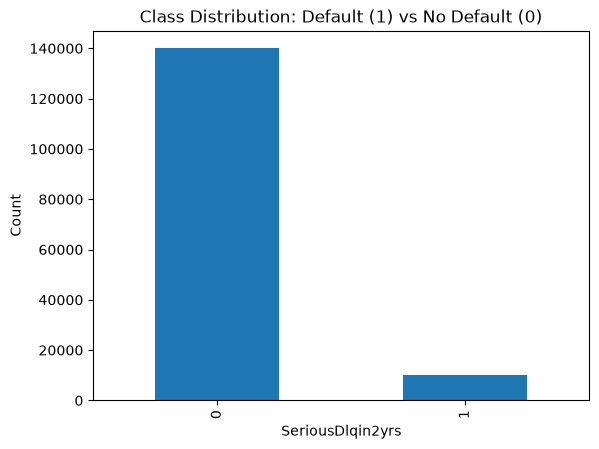

In [64]:
import matplotlib.pyplot as plt

df['SeriousDlqin2yrs'].value_counts().plot(kind='bar')
plt.title('Class Distribution: Default (1) vs No Default (0)')
plt.xlabel('SeriousDlqin2yrs')
plt.ylabel('Count')
plt.show()

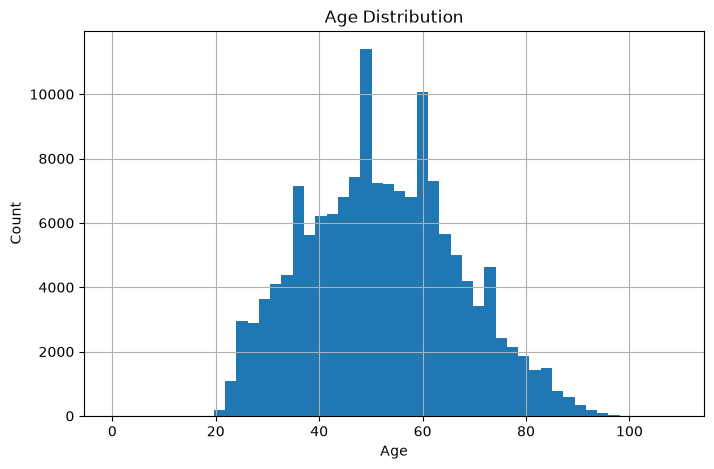

In [65]:
plt.figure(figsize=(8,5))
df['age'].hist(bins=50)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [66]:
df['age'].value_counts().sort_index().loc[45:65]

age
45    3502
46    3714
47    3719
48    3806
49    3837
50    3753
51    3627
52    3609
53    3648
54    3561
55    3416
56    3589
57    3375
58    3443
59    3280
60    3258
61    3522
62    3568
63    3719
64    3058
65    2594
Name: count, dtype: int64

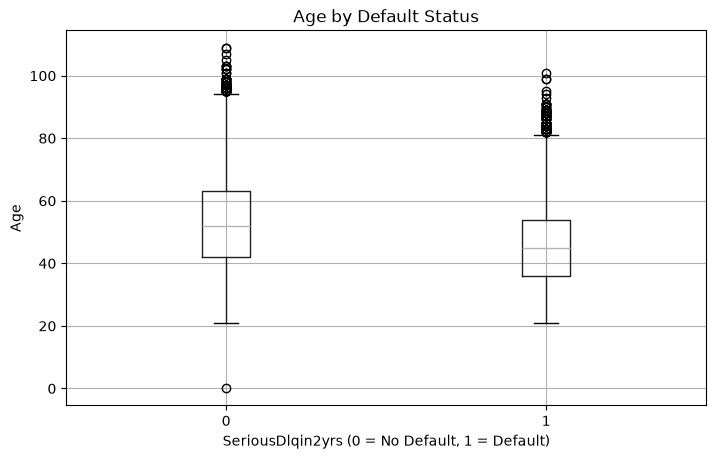

In [67]:
df.boxplot(column='age', by='SeriousDlqin2yrs', figsize=(8,5))
plt.title('Age by Default Status')
plt.suptitle('')
plt.xlabel('SeriousDlqin2yrs (0 = No Default, 1 = Default)')
plt.ylabel('Age')
plt.show()

In [68]:
df['MonthlyIncome'].quantile([0.90, 0.95, 0.99, 0.999, 1.0])

0.900      11666.000
0.950      14587.600
0.990      25000.000
0.999      78395.748
1.000    3008750.000
Name: MonthlyIncome, dtype: float64

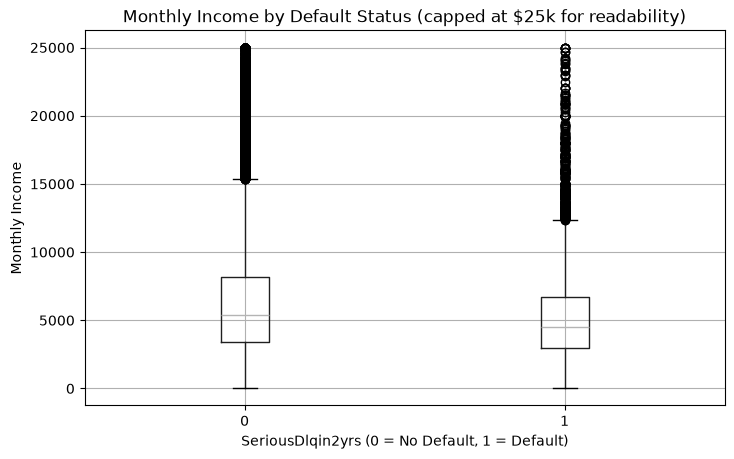

In [69]:
df_income_capped = df[df['MonthlyIncome'] <= 25000]

df_income_capped.boxplot(column='MonthlyIncome', by='SeriousDlqin2yrs', figsize=(8,5))
plt.title('Monthly Income by Default Status (capped at $25k for readability)')
plt.suptitle('')
plt.xlabel('SeriousDlqin2yrs (0 = No Default, 1 = Default)')
plt.ylabel('Monthly Income')
plt.show()

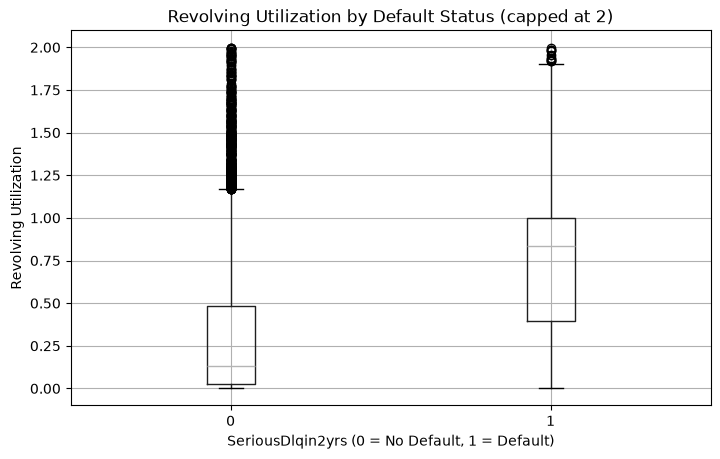

In [70]:
df_util_capped = df[df['RevolvingUtilizationOfUnsecuredLines'] <= 2]

df_util_capped.boxplot(column='RevolvingUtilizationOfUnsecuredLines', by='SeriousDlqin2yrs', figsize=(8,5))
plt.title('Revolving Utilization by Default Status (capped at 2)')
plt.suptitle('')
plt.xlabel('SeriousDlqin2yrs (0 = No Default, 1 = Default)')
plt.ylabel('Revolving Utilization')
plt.show()

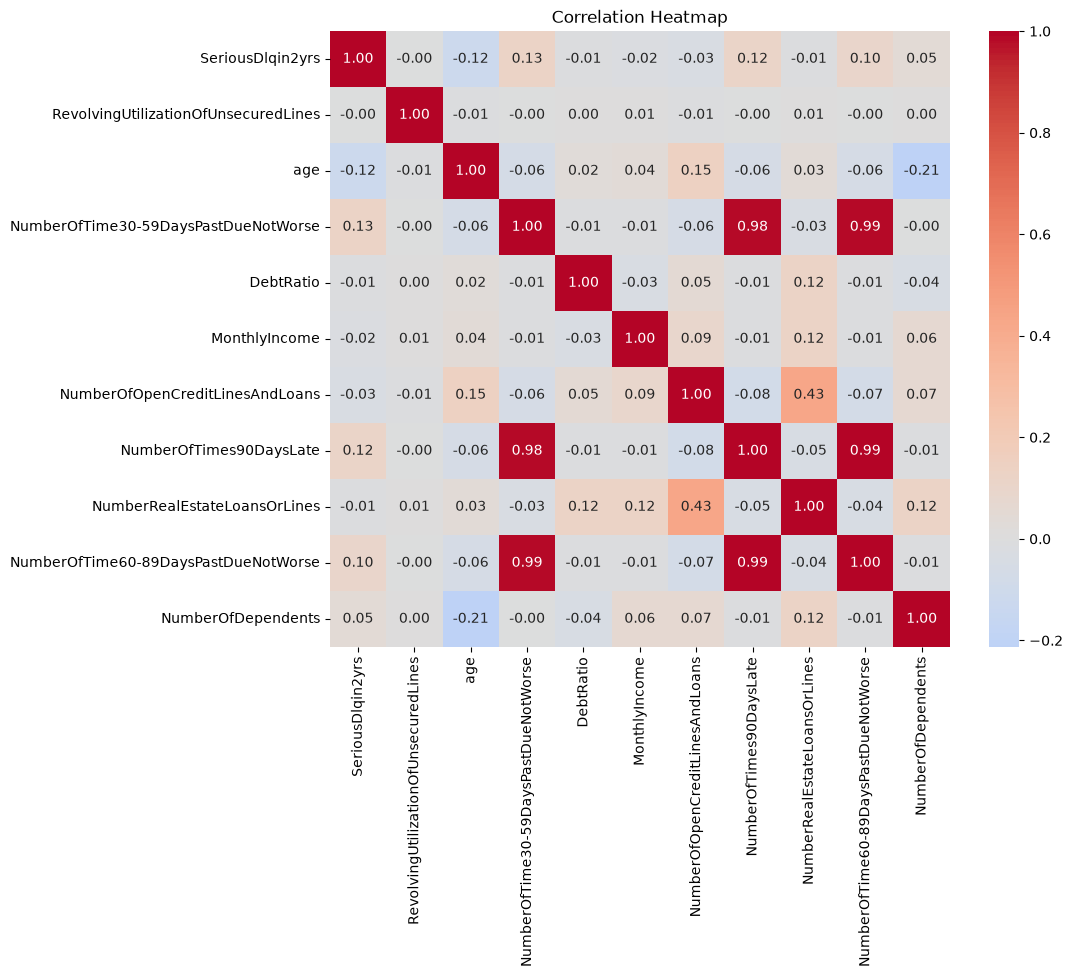

In [71]:
import seaborn as sns

plt.figure(figsize=(10,8))
corr = df.drop(columns=['Unnamed: 0']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [72]:
df_util_capped['RevolvingUtilizationOfUnsecuredLines'].corr(df_util_capped['SeriousDlqin2yrs'])

np.float64(0.28542288045823067)

## Phase 3: EDA Summary

**Dataset:** 150,000 rows, 12 columns (target: `SeriousDlqin2yrs`)

**Class imbalance:** Only ~6.7% of borrowers defaulted — a highly imbalanced target. Will require special handling in modeling (class weights, SMOTE, or similar).

**Missing values:**
- `MonthlyIncome`: ~29,731 missing (~19.8%)
- `NumberOfDependents`: ~3,924 missing (~2.6%)

**Data quality issues found:**
1. **Age = 0** in 1 row — clear data entry error, trivial to fix (drop or impute).
2. **"98" placeholder values** in the three "days past due" columns (269 rows) — not random noise; these rows have a 54.6% default rate (vs 6.7% baseline), suggesting they mark a genuinely high-risk group. Should be treated as a flag/category, not deleted.
3. **`RevolvingUtilizationOfUnsecuredLines` extreme outliers** (371 rows > 2, max 50,708) — appear to be data errors, not meaningful signal (all top outliers had no default). Will cap/winsorize.
4. **`DebtRatio` extreme outliers** (31,045 rows > 2, ~20% of data) — strongly linked to missing `MonthlyIncome` (89.4% of high-DebtRatio rows have missing income, vs 1.7% otherwise). These two issues need to be fixed together in Phase 4.

**Key predictive signals identified:**
- **`RevolvingUtilizationOfUnsecuredLines`**: strongest visual relationship with default — defaulters cluster near/above full credit utilization. (Correlation was misleadingly ~0 due to outliers; jumps to 0.29 once outliers are capped — a reminder to verify correlation against visual EDA.)
- **`age`**: defaulters skew younger (median ~40 vs ~52 for non-defaulters). Correlation: -0.12.
- **`MonthlyIncome`**: mild relationship — defaulters have somewhat lower income, but with heavy overlap.

**Feature redundancy:** The three "days past due" columns are almost perfectly correlated with each other (0.98-0.99) — likely redundant; may need to consolidate or engineer a combined feature in Phase 4/5.

In [73]:
df.shape

(150000, 12)

In [74]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [75]:
df['MonthlyIncome_missing'] = df['MonthlyIncome'].isnull().astype(int)

df['MonthlyIncome_missing'].value_counts()

MonthlyIncome_missing
0    120269
1     29731
Name: count, dtype: int64

In [76]:
median_income = df['MonthlyIncome'].median()
print("Median income:", median_income)

df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)

df['MonthlyIncome'].isnull().sum()

Median income: 5400.0


np.int64(0)

In [77]:
median_dependents = df['NumberOfDependents'].median()
print("Median dependents:", median_dependents)

df['NumberOfDependents'] = df['NumberOfDependents'].fillna(median_dependents)

df['NumberOfDependents'].isnull().sum()

Median dependents: 0.0


np.int64(0)

In [78]:
df.isnull().sum().sum()

np.int64(0)

In [79]:
df = df.drop(columns=['Unnamed: 0'])

df.columns.tolist()

['SeriousDlqin2yrs',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents',
 'MonthlyIncome_missing']

In [80]:
df.duplicated().sum()

np.int64(767)

In [81]:
df = df.drop_duplicates()

df.shape

(149233, 12)

In [82]:
print("Rows with age = 0:", (df['age'] == 0).sum())
print()
print(df['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index(ascending=False).head(10))

Rows with age = 0: 1

NumberOfTime30-59DaysPastDueNotWorse
98    211
96      5
13      1
12      2
11      1
10      4
9      12
8      25
7      54
6     140
Name: count, dtype: int64


In [83]:
df = df[df['age'] != 0]

df.shape

(149232, 12)

In [84]:
df['WasFlagged_9698'] = ((df['NumberOfTime30-59DaysPastDueNotWorse'] >= 96) |
                          (df['NumberOfTime60-89DaysPastDueNotWorse'] >= 96) |
                          (df['NumberOfTimes90DaysLate'] >= 96)).astype(int)

df['WasFlagged_9698'].value_counts()

WasFlagged_9698
0    149016
1       216
Name: count, dtype: int64

In [85]:
for col in ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']:
    realistic_max = df[df[col] < 96][col].max()
    print(col, "->", realistic_max)

NumberOfTime30-59DaysPastDueNotWorse -> 13
NumberOfTime60-89DaysPastDueNotWorse -> 11
NumberOfTimes90DaysLate -> 17


In [86]:
df.loc[df['NumberOfTime30-59DaysPastDueNotWorse'] >= 96, 'NumberOfTime30-59DaysPastDueNotWorse'] = 13
df.loc[df['NumberOfTime60-89DaysPastDueNotWorse'] >= 96, 'NumberOfTime60-89DaysPastDueNotWorse'] = 11
df.loc[df['NumberOfTimes90DaysLate'] >= 96, 'NumberOfTimes90DaysLate'] = 17

df[['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']].max()

NumberOfTime30-59DaysPastDueNotWorse    13
NumberOfTime60-89DaysPastDueNotWorse    11
NumberOfTimes90DaysLate                 17
dtype: int64

In [87]:
print("RevolvingUtilization > 2:", (df['RevolvingUtilizationOfUnsecuredLines'] > 2).sum())
print("DebtRatio > 2:", (df['DebtRatio'] > 2).sum())

RevolvingUtilization > 2: 371
DebtRatio > 2: 31034


In [88]:
df[df['DebtRatio'] > 2]['MonthlyIncome_missing'].value_counts()

MonthlyIncome_missing
1    27733
0     3301
Name: count, dtype: int64

In [89]:
print("DebtRatio 99th percentile:", df['DebtRatio'].quantile(0.99))
print("RevolvingUtilization 99th percentile:", df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99))

DebtRatio 99th percentile: 4988.070000000007
RevolvingUtilization 99th percentile: 1.093976506


In [90]:
debt_cap = df['DebtRatio'].quantile(0.99)
revolv_cap = df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)

df['DebtRatio'] = df['DebtRatio'].clip(upper=debt_cap)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=revolv_cap)

print("New DebtRatio max:", df['DebtRatio'].max())
print("New RevolvingUtilization max:", df['RevolvingUtilizationOfUnsecuredLines'].max())

New DebtRatio max: 4988.070000000007
New RevolvingUtilization max: 1.093976506


In [91]:
print("Final shape:", df.shape)
print()
print("Missing values total:", df.isnull().sum().sum())
print()
df.dtypes

Final shape: (149232, 13)

Missing values total: 0



SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
MonthlyIncome_missing                     int64
WasFlagged_9698                           int64
dtype: object

In [92]:
df.to_csv('data/cleaned_data.csv', index=False)
print("Saved!")

Saved!


In [93]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/cleaned_data.csv')

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nColumns:", list(df.columns))
print("\nMissing values:", df.isnull().sum().sum())
df.head()

Shape: (149232, 13)

Dtypes:
 SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
MonthlyIncome_missing                     int64
WasFlagged_9698                           int64
dtype: object

Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_missing', 'Wa

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,WasFlagged_9698
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0,0


In [94]:
delinquency_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

df['TotalPastDue'] = df[delinquency_cols].sum(axis=1)
df['EverDelinquent'] = (df['TotalPastDue'] > 0).astype(int)

def worst_delinquency(row):
    if row['NumberOfTimes90DaysLate'] > 0:
        return 3
    elif row['NumberOfTime60-89DaysPastDueNotWorse'] > 0:
        return 2
    elif row['NumberOfTime30-59DaysPastDueNotWorse'] > 0:
        return 1
    else:
        return 0

df['WorstDelinquency'] = df.apply(worst_delinquency, axis=1)

# Verify
print(df[delinquency_cols + ['TotalPastDue', 'EverDelinquent', 'WorstDelinquency']].head(10))
print("\nEverDelinquent value counts:\n", df['EverDelinquent'].value_counts())
print("\nWorstDelinquency value counts:\n", df['WorstDelinquency'].value_counts().sort_index())
print("\nDefault rate by EverDelinquent:\n", df.groupby('EverDelinquent')['SeriousDlqin2yrs'].mean())
print("\nDefault rate by WorstDelinquency:\n", df.groupby('WorstDelinquency')['SeriousDlqin2yrs'].mean())

   NumberOfTime30-59DaysPastDueNotWorse  NumberOfTime60-89DaysPastDueNotWorse  \
0                                     2                                     0   
1                                     0                                     0   
2                                     1                                     0   
3                                     0                                     0   
4                                     1                                     0   
5                                     0                                     0   
6                                     0                                     0   
7                                     0                                     0   
8                                     0                                     0   
9                                     0                                     0   

   NumberOfTimes90DaysLate  TotalPastDue  EverDelinquent  WorstDelinquency  
0                        0     

In [95]:
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)
df['DebtToIncomeProxy'] = df['MonthlyIncome'] * df['DebtRatio']
df['IsZeroIncome'] = (df['MonthlyIncome'] == 0).astype(int)

# Verify
print(df[['MonthlyIncome', 'NumberOfDependents', 'IncomePerDependent',
          'DebtRatio', 'DebtToIncomeProxy', 'IsZeroIncome']].head(10))

print("\nIsZeroIncome value counts:\n", df['IsZeroIncome'].value_counts())
print("\nDefault rate by IsZeroIncome:\n", df.groupby('IsZeroIncome')['SeriousDlqin2yrs'].mean())

print("\nIncomePerDependent describe:\n", df['IncomePerDependent'].describe())
print("\nDebtToIncomeProxy describe:\n", df['DebtToIncomeProxy'].describe())

   MonthlyIncome  NumberOfDependents  IncomePerDependent    DebtRatio  \
0         9120.0                 2.0         3040.000000     0.802982   
1         2600.0                 1.0         1300.000000     0.121876   
2         3042.0                 0.0         3042.000000     0.085113   
3         3300.0                 0.0         3300.000000     0.036050   
4        63588.0                 0.0        63588.000000     0.024926   
5         3500.0                 1.0         1750.000000     0.375607   
6         5400.0                 0.0         5400.000000  4988.070000   
7         3500.0                 0.0         3500.000000     0.209940   
8         5400.0                 0.0         5400.000000    46.000000   
9        23684.0                 2.0         7894.666667     0.606291   

   DebtToIncomeProxy  IsZeroIncome  
0       7.323197e+03             0  
1       3.168781e+02             0  
2       2.589149e+02             0  
3       1.189640e+02             0  
4       1.5

In [96]:
cap_value = df['DebtToIncomeProxy'].quantile(0.99)
print(f"99th percentile cap value: {cap_value:.2f}")

n_capped = (df['DebtToIncomeProxy'] > cap_value).sum()
print(f"Rows capped: {n_capped} ({n_capped/len(df)*100:.2f}%)")

df['DebtToIncomeProxy'] = df['DebtToIncomeProxy'].clip(upper=cap_value)

print("\nDebtToIncomeProxy describe after capping:\n", df['DebtToIncomeProxy'].describe())

99th percentile cap value: 26438400.00
Rows capped: 1492 (1.00%)

DebtToIncomeProxy describe after capping:
 count    1.492320e+05
mean     1.614241e+06
std      4.770787e+06
min      0.000000e+00
25%      7.949415e+02
50%      2.121732e+03
75%      4.837583e+03
max      2.643840e+07
Name: DebtToIncomeProxy, dtype: float64


In [97]:
# Define "suspect" as DebtRatio far outside what a real ratio should be
# A DebtRatio > 10 (i.e. debt payments 10x monthly income) is already extreme for a genuine ratio
suspect = df[df['DebtRatio'] > 10]

print(f"Suspect rows (DebtRatio > 10): {len(suspect)} ({len(suspect)/len(df)*100:.2f}%)")
print(f"\nDebtRatio distribution overall:\n{df['DebtRatio'].describe()}")
print(f"\nDebtRatio distribution for suspect rows:\n{suspect['DebtRatio'].describe()}")

# Does this cluster correlate with MonthlyIncome_missing (i.e. income was originally missing/imputed)?
print(f"\nMonthlyIncome_missing rate overall: {df['MonthlyIncome_missing'].mean():.4f}")
print(f"MonthlyIncome_missing rate in suspect rows: {suspect['MonthlyIncome_missing'].mean():.4f}")

# Does MonthlyIncome tend to be small/suspicious in these rows?
print(f"\nMonthlyIncome describe overall:\n{df['MonthlyIncome'].describe()}")
print(f"\nMonthlyIncome describe in suspect rows:\n{suspect['MonthlyIncome'].describe()}")

# Default rate comparison
print(f"\nDefault rate overall: {df['SeriousDlqin2yrs'].mean():.4f}")
print(f"Default rate in suspect rows: {suspect['SeriousDlqin2yrs'].mean():.4f}")

Suspect rows (DebtRatio > 10): 28871 (19.35%)

DebtRatio distribution overall:
count    149232.000000
mean        318.257379
std         909.473588
min           0.000000
25%           0.178094
50%           0.368577
75%           0.877091
max        4988.070000
Name: DebtRatio, dtype: float64

DebtRatio distribution for suspect rows:
count    28871.000000
mean      1643.292356
std       1448.659739
min         10.138614
25%        373.000000
50%       1342.000000
75%       2503.000000
max       4988.070000
Name: DebtRatio, dtype: float64

MonthlyIncome_missing rate overall: 0.1948
MonthlyIncome_missing rate in suspect rows: 0.9271

MonthlyIncome describe overall:
count    1.492320e+05
mean     6.426777e+03
std      1.292250e+04
min      0.000000e+00
25%      3.900000e+03
50%      5.400000e+03
75%      7.409000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

MonthlyIncome describe in suspect rows:
count    28871.000000
mean      5014.736552
std       1397.857538
min     

In [98]:
# Compute cap from clean rows only (income was genuinely observed)
clean_cap = df.loc[df['MonthlyIncome_missing'] == 0, 'DebtRatio'].quantile(0.99)
print(f"99th percentile DebtRatio, clean rows only: {clean_cap:.4f}")

# Compare to old (whole-column) cap for reference
old_cap = df['DebtRatio'].quantile(0.99)
print(f"99th percentile DebtRatio, whole column (old, contaminated): {old_cap:.4f}")

n_recapped = (df['DebtRatio'] > clean_cap).sum()
print(f"\nRows re-capped: {n_recapped} ({n_recapped/len(df)*100:.2f}%)")

df['DebtRatio'] = df['DebtRatio'].clip(upper=clean_cap)

print("\nDebtRatio describe after re-cap:\n", df['DebtRatio'].describe())

# Rebuild DebtToIncomeProxy from the corrected DebtRatio
df['DebtToIncomeProxy'] = df['MonthlyIncome'] * df['DebtRatio']
new_cap = df['DebtToIncomeProxy'].quantile(0.99)
df['DebtToIncomeProxy'] = df['DebtToIncomeProxy'].clip(upper=new_cap)

print("\nDebtToIncomeProxy describe after rebuild + recap:\n", df['DebtToIncomeProxy'].describe())

99th percentile DebtRatio, clean rows only: 662.9800
99th percentile DebtRatio, whole column (old, contaminated): 4987.4283

Rows re-capped: 19304 (12.94%)

DebtRatio describe after re-cap:
 count    149232.000000
mean         99.478591
std         228.685224
min           0.000000
25%           0.178094
50%           0.368577
75%           0.877091
max         662.980000
Name: DebtRatio, dtype: float64

DebtToIncomeProxy describe after rebuild + recap:
 count    1.492320e+05
mean     5.018334e+05
std      1.201944e+06
min      0.000000e+00
25%      7.872481e+02
50%      2.120011e+03
75%      4.835660e+03
max      3.580092e+06
Name: DebtToIncomeProxy, dtype: float64


In [99]:
# Sanity check: DebtRatio should still show a sensible (roughly monotonic or at least stable) 
# relationship with default rate after recapping
df['DebtRatio_bin'] = pd.qcut(df['DebtRatio'], q=5, duplicates='drop')
print("Default rate by DebtRatio quintile:\n", df.groupby('DebtRatio_bin', observed=True)['SeriousDlqin2yrs'].mean())
df.drop(columns=['DebtRatio_bin'], inplace=True)

# Add log-transformed versions of the skewed continuous features (log1p handles zeros safely)
skewed_cols = ['DebtRatio', 'DebtToIncomeProxy', 'MonthlyIncome', 'RevolvingUtilizationOfUnsecuredLines']
for col in skewed_cols:
    df[f'{col}_log'] = np.log1p(df[col])

print("\nLog-transformed columns added:", [f'{c}_log' for c in skewed_cols])
print("\nSkew comparison (original vs log):")
for col in skewed_cols:
    print(f"{col}: {df[col].skew():.2f}  ->  {col}_log: {df[f'{col}_log'].skew():.2f}")

Default rate by DebtRatio quintile:
 DebtRatio_bin
(-0.001, 0.137]    0.062016
(0.137, 0.29]      0.056590
(0.29, 0.47]       0.062119
(0.47, 4.309]      0.099176
(4.309, 662.98]    0.055282
Name: SeriousDlqin2yrs, dtype: float64

Log-transformed columns added: ['DebtRatio_log', 'DebtToIncomeProxy_log', 'MonthlyIncome_log', 'RevolvingUtilizationOfUnsecuredLines_log']

Skew comparison (original vs log):
DebtRatio: 1.98  ->  DebtRatio_log: 1.64
DebtToIncomeProxy: 2.09  ->  DebtToIncomeProxy_log: 0.47
MonthlyIncome: 126.82  ->  MonthlyIncome_log: -4.94
RevolvingUtilizationOfUnsecuredLines: 0.91  ->  RevolvingUtilizationOfUnsecuredLines_log: 0.72


In [100]:
df['AgeBin'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 120],
                       labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+'])

print(df['AgeBin'].value_counts().sort_index())
print("\nDefault rate by AgeBin:\n", df.groupby('AgeBin', observed=True)['SeriousDlqin2yrs'].mean())

AgeBin
<25       2822
25-34    18394
35-44    29766
45-54    36626
55-64    33294
65+      28330
Name: count, dtype: int64

Default rate by AgeBin:
 AgeBin
<25      0.115875
25-34    0.111395
35-44    0.088221
45-54    0.075957
55-64    0.045954
65+      0.024356
Name: SeriousDlqin2yrs, dtype: float64


In [101]:
age_dummies = pd.get_dummies(df['AgeBin'], prefix='Age', drop_first=True)
df = pd.concat([df, age_dummies], axis=1)

print("New age dummy columns:", list(age_dummies.columns))
print("\nShape after adding age dummies:", df.shape)
print(df[age_dummies.columns].head())

New age dummy columns: ['Age_25-34', 'Age_35-44', 'Age_45-54', 'Age_55-64', 'Age_65+']

Shape after adding age dummies: (149232, 29)
   Age_25-34  Age_35-44  Age_45-54  Age_55-64  Age_65+
0      False       True      False      False    False
1      False       True      False      False    False
2      False       True      False      False    False
3       True      False      False      False    False
4      False      False       True      False    False


In [102]:
# Cast age dummy booleans to int for consistency
age_dummy_cols = [c for c in df.columns if c.startswith('Age_')]
df[age_dummy_cols] = df[age_dummy_cols].astype(int)

print("Final shape:", df.shape)
print("\nAll columns:\n", list(df.columns))
print("\nDtypes:\n", df.dtypes)
print("\nMissing values total:", df.isnull().sum().sum())

# Correlation of all engineered features with the target
engineered_cols = ['TotalPastDue', 'EverDelinquent', 'WorstDelinquency',
                    'IncomePerDependent', 'DebtToIncomeProxy', 'IsZeroIncome',
                    'DebtRatio_log', 'DebtToIncomeProxy_log', 'MonthlyIncome_log',
                    'RevolvingUtilizationOfUnsecuredLines_log'] + age_dummy_cols

corr_with_target = df[engineered_cols + ['SeriousDlqin2yrs']].corr()['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs')
print("\nCorrelation of engineered features with target, sorted:\n", corr_with_target.sort_values(ascending=False))

Final shape: (149232, 29)

All columns:
 ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_missing', 'WasFlagged_9698', 'TotalPastDue', 'EverDelinquent', 'WorstDelinquency', 'IncomePerDependent', 'DebtToIncomeProxy', 'IsZeroIncome', 'DebtRatio_log', 'DebtToIncomeProxy_log', 'MonthlyIncome_log', 'RevolvingUtilizationOfUnsecuredLines_log', 'AgeBin', 'Age_25-34', 'Age_35-44', 'Age_45-54', 'Age_55-64', 'Age_65+']

Dtypes:
 SeriousDlqin2yrs                               int64
RevolvingUtilizationOfUnsecuredLines         float64
age                                            int64
NumberOfTime30-59DaysPastDueNotWorse           int64
DebtRatio                                    float64
MonthlyIncome                                float64


In [103]:
df.to_csv('data/featured_data.csv', index=False)
print("Saved. Final shape:", df.shape)

Saved. Final shape: (149232, 29)


In [104]:
from sklearn.model_selection import train_test_split

# Load featured data if not already in memory
# df = pd.read_csv('data/featured_data.csv')

target_col = 'SeriousDlqin2yrs'  # confirm this is your target column name

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train default rate:", y_train.mean().round(4))
print("y_test default rate:", y_test.mean().round(4))

X_train: (119385, 28)
X_test: (29847, 28)
y_train default rate: 0.067
y_test default rate: 0.067


In [105]:
# Identify binary/dummy columns (already 0/1) vs continuous columns
binary_like_cols = [col for col in X_train.columns if X_train[col].nunique() <= 2]
continuous_cols = [col for col in X_train.columns if col not in binary_like_cols]

print("Binary/dummy columns ({}):".format(len(binary_like_cols)))
print(binary_like_cols)
print()
print("Continuous columns ({}):".format(len(continuous_cols)))
print(continuous_cols)

Binary/dummy columns (9):
['MonthlyIncome_missing', 'WasFlagged_9698', 'EverDelinquent', 'IsZeroIncome', 'Age_25-34', 'Age_35-44', 'Age_45-54', 'Age_55-64', 'Age_65+']

Continuous columns (19):
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'TotalPastDue', 'WorstDelinquency', 'IncomePerDependent', 'DebtToIncomeProxy', 'DebtRatio_log', 'DebtToIncomeProxy_log', 'MonthlyIncome_log', 'RevolvingUtilizationOfUnsecuredLines_log', 'AgeBin']


In [106]:
print(X_train['AgeBin'].dtype)
print(X_train['AgeBin'].unique())

category
['65+', '25-34', '55-64', '45-54', '35-44', '<25']
Categories (6, str): ['<25' < '25-34' < '35-44' < '45-54' < '55-64' < '65+']


In [107]:
# Confirm which age category is missing from the dummies (the dropped reference category)
age_dummy_cols = ['Age_25-34', 'Age_35-44', 'Age_45-54', 'Age_55-64', 'Age_65+']
print("AgeBin categories:", list(X_train['AgeBin'].cat.categories))
print("Age dummy columns present:", age_dummy_cols)

# Drop AgeBin from both train and test — the dummies already carry this info
X_train = X_train.drop(columns=['AgeBin'])
X_test = X_test.drop(columns=['AgeBin'])

# Rebuild column lists now that AgeBin is gone
binary_like_cols = [col for col in X_train.columns if X_train[col].nunique() <= 2]
continuous_cols = [col for col in X_train.columns if col not in binary_like_cols]

print("\nX_train shape after drop:", X_train.shape)
print("Binary/dummy columns ({}):".format(len(binary_like_cols)))
print(binary_like_cols)
print("\nContinuous columns ({}):".format(len(continuous_cols)))
print(continuous_cols)

AgeBin categories: ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
Age dummy columns present: ['Age_25-34', 'Age_35-44', 'Age_45-54', 'Age_55-64', 'Age_65+']

X_train shape after drop: (119385, 27)
Binary/dummy columns (9):
['MonthlyIncome_missing', 'WasFlagged_9698', 'EverDelinquent', 'IsZeroIncome', 'Age_25-34', 'Age_35-44', 'Age_45-54', 'Age_55-64', 'Age_65+']

Continuous columns (18):
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'TotalPastDue', 'WorstDelinquency', 'IncomePerDependent', 'DebtToIncomeProxy', 'DebtRatio_log', 'DebtToIncomeProxy_log', 'MonthlyIncome_log', 'RevolvingUtilizationOfUnsecuredLines_log']


In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print()
print("Train scaled means (should be ~0):")
print(X_train_scaled[continuous_cols].mean().round(3))
print()
print("Train scaled stds (should be ~1):")
print(X_train_scaled[continuous_cols].std().round(3))

X_train_scaled shape: (119385, 27)
X_test_scaled shape: (29847, 27)

Train scaled means (should be ~0):
RevolvingUtilizationOfUnsecuredLines       -0.0
age                                         0.0
NumberOfTime30-59DaysPastDueNotWorse        0.0
DebtRatio                                   0.0
MonthlyIncome                               0.0
NumberOfOpenCreditLinesAndLoans             0.0
NumberOfTimes90DaysLate                     0.0
NumberRealEstateLoansOrLines                0.0
NumberOfTime60-89DaysPastDueNotWorse        0.0
NumberOfDependents                          0.0
TotalPastDue                                0.0
WorstDelinquency                            0.0
IncomePerDependent                          0.0
DebtToIncomeProxy                           0.0
DebtRatio_log                               0.0
DebtToIncomeProxy_log                       0.0
MonthlyIncome_log                           0.0
RevolvingUtilizationOfUnsecuredLines_log    0.0
dtype: float64

Train scaled std

In [109]:
import pandas as pd

corr_matrix = X_train[continuous_cols].corr()

# Find highly correlated pairs (excluding self-correlation)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

high_corr_pairs_sorted = sorted(high_corr_pairs, key=lambda x: -abs(x[2]))
for pair in high_corr_pairs_sorted:
    print(pair)

print(f"\nTotal highly correlated pairs (|r| > 0.8): {len(high_corr_pairs_sorted)}")

('RevolvingUtilizationOfUnsecuredLines', 'RevolvingUtilizationOfUnsecuredLines_log', np.float64(0.996))
('DebtRatio', 'DebtToIncomeProxy', np.float64(0.961))
('DebtRatio', 'DebtRatio_log', np.float64(0.953))
('DebtToIncomeProxy', 'DebtRatio_log', np.float64(0.914))
('NumberOfTimes90DaysLate', 'TotalPastDue', np.float64(0.881))
('NumberOfTime60-89DaysPastDueNotWorse', 'TotalPastDue', np.float64(0.861))
('NumberOfTime30-59DaysPastDueNotWorse', 'TotalPastDue', np.float64(0.855))
('MonthlyIncome', 'IncomePerDependent', np.float64(0.816))
('DebtToIncomeProxy', 'DebtToIncomeProxy_log', np.float64(0.806))

Total highly correlated pairs (|r| > 0.8): 9


In [110]:
# Columns to drop ONLY for the Logistic Regression feature set (redundant/multicollinear)
lr_drop_cols = [
    'RevolvingUtilizationOfUnsecuredLines',      # keep _log version
    'DebtRatio', 'DebtRatio_log', 'DebtToIncomeProxy',  # keep DebtToIncomeProxy_log
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',                   # keep TotalPastDue, WorstDelinquency, EverDelinquent
    'MonthlyIncome'                              # keep MonthlyIncome_log, IncomePerDependent
]

X_train_lr = X_train_scaled.drop(columns=lr_drop_cols)
X_test_lr = X_test_scaled.drop(columns=lr_drop_cols)

print("X_train_lr shape:", X_train_lr.shape)
print("X_test_lr shape:", X_test_lr.shape)

# Re-check correlations on the reduced set
remaining_continuous = [c for c in continuous_cols if c not in lr_drop_cols]
corr_check = X_train_lr[remaining_continuous].corr()

high_corr_remaining = []
for i in range(len(corr_check.columns)):
    for j in range(i+1, len(corr_check.columns)):
        val = corr_check.iloc[i, j]
        if abs(val) > 0.8:
            high_corr_remaining.append((corr_check.columns[i], corr_check.columns[j], round(val, 3)))

print("\nRemaining high-correlation pairs (|r| > 0.8):", high_corr_remaining)

X_train_lr shape: (119385, 19)
X_test_lr shape: (29847, 19)

Remaining high-correlation pairs (|r| > 0.8): []


In [111]:
import joblib

X_train.to_csv('data/X_train.csv', index=False)
X_test.to_csv('data/X_test.csv', index=False)
X_train_lr.to_csv('data/X_train_lr.csv', index=False)
X_test_lr.to_csv('data/X_test_lr.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)

joblib.dump(scaler, 'data/scaler.pkl')

print("Saved!")

Saved!


In [112]:
import pandas as pd
import numpy as np
import joblib

# Load the raw/unscaled sets (for tree-based models)
X_train = pd.read_csv('data/X_train.csv')
X_test = pd.read_csv('data/X_test.csv')

# Load the scaled/decorrelated sets (for Logistic Regression)
X_train_lr = pd.read_csv('data/X_train_lr.csv')
X_test_lr = pd.read_csv('data/X_test_lr.csv')

# Load targets
y_train = pd.read_csv('data/y_train.csv').squeeze()
y_test = pd.read_csv('data/y_test.csv').squeeze()

# Load the fitted scaler (not needed for training, but good to confirm it loads)
scaler = joblib.load('data/scaler.pkl')

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_train_lr:", X_train_lr.shape)
print("X_test_lr:", X_test_lr.shape)
print("y_train:", y_train.shape, "| default rate:", y_train.mean().round(4))
print("y_test:", y_test.shape, "| default rate:", y_test.mean().round(4))

print("\nX_train columns:")
print(list(X_train.columns))

print("\nX_train_lr columns:")
print(list(X_train_lr.columns))

X_train: (119385, 27)
X_test: (29847, 27)
X_train_lr: (119385, 19)
X_test_lr: (29847, 19)
y_train: (119385,) | default rate: 0.067
y_test: (29847,) | default rate: 0.067

X_train columns:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_missing', 'WasFlagged_9698', 'TotalPastDue', 'EverDelinquent', 'WorstDelinquency', 'IncomePerDependent', 'DebtToIncomeProxy', 'IsZeroIncome', 'DebtRatio_log', 'DebtToIncomeProxy_log', 'MonthlyIncome_log', 'RevolvingUtilizationOfUnsecuredLines_log', 'Age_25-34', 'Age_35-44', 'Age_45-54', 'Age_55-64', 'Age_65+']

X_train_lr columns:
['age', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'MonthlyIncome_missing', 'WasFlagged_9698', 'TotalPastDue', 'EverDelinquent', 'WorstDelinquen

In [113]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_lr, y_train)

print("Logistic Regression trained.")
print("Number of iterations run:", log_reg.n_iter_)
print("Converged:", log_reg.n_iter_[0] < log_reg.max_iter)

# Quick look at coefficients, sorted by magnitude
coef_df = pd.DataFrame({
    'feature': X_train_lr.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nCoefficients (sorted by absolute magnitude):")
print(coef_df.to_string(index=False))

Logistic Regression trained.
Number of iterations run: [101]
Converged: True

Coefficients (sorted by absolute magnitude):
                                 feature  coefficient
                         WasFlagged_9698    -8.270338
                            IsZeroIncome    -1.375570
                                 Age_65+    -0.760773
RevolvingUtilizationOfUnsecuredLines_log     0.720904
                               Age_55-64    -0.604419
                        WorstDelinquency     0.437624
                            TotalPastDue     0.435697
                          EverDelinquent     0.355122
                               Age_45-54    -0.321183
                               Age_35-44    -0.287639
         NumberOfOpenCreditLinesAndLoans     0.182201
                   MonthlyIncome_missing     0.159558
            NumberRealEstateLoansOrLines     0.158292
                   DebtToIncomeProxy_log    -0.118134
                       MonthlyIncome_log    -0.104620
             

In [114]:
# 1. Check the relationship between the flag and the target directly
print("Default rate by WasFlagged_9698:")
print(y_train.groupby(X_train_lr['WasFlagged_9698']).mean())
print()
print("Row counts by WasFlagged_9698:")
print(X_train_lr['WasFlagged_9698'].value_counts())

# 2. Check how entangled the flag is with the delinquency aggregates
print("\nCorrelation of WasFlagged_9698 with delinquency aggregates:")
print(X_train_lr[['WasFlagged_9698', 'TotalPastDue', 'WorstDelinquency', 'EverDelinquent']].corr()['WasFlagged_9698'])

# 3. Cross-tab: among flagged rows, what does WorstDelinquency look like?
print("\nWorstDelinquency distribution when WasFlagged_9698 == 1:")
print(X_train_lr.loc[X_train_lr['WasFlagged_9698'] == 1, 'WorstDelinquency'].describe())

print("\nWorstDelinquency distribution when WasFlagged_9698 == 0:")
print(X_train_lr.loc[X_train_lr['WasFlagged_9698'] == 0, 'WorstDelinquency'].describe())

Default rate by WasFlagged_9698:
WasFlagged_9698
0    0.066267
1    0.605882
Name: SeriousDlqin2yrs, dtype: float64

Row counts by WasFlagged_9698:
WasFlagged_9698
0    119215
1       170
Name: count, dtype: int64

Correlation of WasFlagged_9698 with delinquency aggregates:
WasFlagged_9698     1.000000
TotalPastDue        0.811802
WorstDelinquency    0.126790
EverDelinquent      0.074756
Name: WasFlagged_9698, dtype: float64

WorstDelinquency distribution when WasFlagged_9698 == 1:
count    170.000000
mean       3.357578
std        0.000000
min        3.357578
25%        3.357578
50%        3.357578
75%        3.357578
max        3.357578
Name: WorstDelinquency, dtype: float64

WorstDelinquency distribution when WasFlagged_9698 == 0:
count    119215.000000
mean         -0.004788
std           0.992641
min          -0.438777
25%          -0.438777
50%          -0.438777
75%          -0.438777
max           3.357578
Name: WorstDelinquency, dtype: float64


In [115]:
lr_features = [c for c in X_train_lr.columns if c != 'WasFlagged_9698']

X_train_lr2 = X_train_lr[lr_features]
X_test_lr2 = X_test_lr[lr_features]

log_reg2 = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
log_reg2.fit(X_train_lr2, y_train)

print("Converged:", log_reg2.n_iter_[0] < log_reg2.max_iter, "| iterations:", log_reg2.n_iter_)

coef_df2 = pd.DataFrame({
    'feature': lr_features,
    'coefficient': log_reg2.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nCoefficients (sorted by absolute magnitude):")
print(coef_df2.to_string(index=False))

Converged: True | iterations: [41]

Coefficients (sorted by absolute magnitude):
                                 feature  coefficient
                            IsZeroIncome    -1.326784
RevolvingUtilizationOfUnsecuredLines_log     0.723630
                                 Age_65+    -0.559304
                        WorstDelinquency     0.478709
                               Age_55-64    -0.442854
                          EverDelinquent     0.425079
                            TotalPastDue     0.276239
                               Age_45-54    -0.190310
                               Age_35-44    -0.185784
         NumberOfOpenCreditLinesAndLoans     0.184323
            NumberRealEstateLoansOrLines     0.154198
                                     age    -0.118458
                   MonthlyIncome_missing     0.116166
                       MonthlyIncome_log    -0.105063
                   DebtToIncomeProxy_log    -0.099070
                      IncomePerDependent    -0.079000
 

In [116]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, roc_curve
)

# Predicted probabilities and class labels (default threshold 0.5)
y_pred_proba = log_reg2.predict_proba(X_test_lr2)[:, 1]
y_pred = log_reg2.predict(X_test_lr2)

print("=== Logistic Regression — Test Set Performance ===\n")

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test, y_pred_proba):.4f}")

print("\nConfusion Matrix (rows=actual, cols=predicted):")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default'], digits=4))

# What fraction of test set is being flagged as default at threshold 0.5?
print(f"Predicted default rate at threshold 0.5: {y_pred.mean():.4f}")
print(f"Actual default rate: {y_test.mean():.4f}")

=== Logistic Regression — Test Set Performance ===

ROC-AUC: 0.8584
PR-AUC (Average Precision): 0.3745

Confusion Matrix (rows=actual, cols=predicted):
[[22512  5334]
 [  499  1502]]

Classification Report:
              precision    recall  f1-score   support

  No Default     0.9783    0.8084    0.8853     27846
     Default     0.2197    0.7506    0.3399      2001

    accuracy                         0.8046     29847
   macro avg     0.5990    0.7795    0.6126     29847
weighted avg     0.9275    0.8046    0.8487     29847

Predicted default rate at threshold 0.5: 0.2290
Actual default rate: 0.0670


In [118]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest trained.")
print("Number of trees:", rf.n_estimators)

# Feature importances
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature importances:")
print(importance_df.to_string(index=False))

Random Forest trained.
Number of trees: 300

Feature importances:
                                 feature  importance
                        WorstDelinquency    0.166644
    RevolvingUtilizationOfUnsecuredLines    0.145879
                            TotalPastDue    0.144493
RevolvingUtilizationOfUnsecuredLines_log    0.135571
                          EverDelinquent    0.135544
                 NumberOfTimes90DaysLate    0.057007
    NumberOfTime30-59DaysPastDueNotWorse    0.032446
                                     age    0.027270
    NumberOfTime60-89DaysPastDueNotWorse    0.024473
         NumberOfOpenCreditLinesAndLoans    0.015895
                           DebtRatio_log    0.014672
                               DebtRatio    0.014364
                       DebtToIncomeProxy    0.013264
                   DebtToIncomeProxy_log    0.012740
                      IncomePerDependent    0.011461
            NumberRealEstateLoansOrLines    0.010505
                       MonthlyInc

In [119]:
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

print("=== Random Forest — Test Set Performance ===\n")

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test, y_pred_proba_rf):.4f}")

print("\nConfusion Matrix (rows=actual, cols=predicted):")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Default', 'Default'], digits=4))

print(f"Predicted default rate at threshold 0.5: {y_pred_rf.mean():.4f}")
print(f"Actual default rate: {y_test.mean():.4f}")

# Side-by-side comparison with Logistic Regression
print("\n=== LR vs RF Comparison ===")
print(f"{'Metric':<25}{'LogReg':>10}{'RandForest':>12}")
print(f"{'ROC-AUC':<25}{roc_auc_score(y_test, y_pred_proba):>10.4f}{roc_auc_score(y_test, y_pred_proba_rf):>12.4f}")
print(f"{'PR-AUC':<25}{average_precision_score(y_test, y_pred_proba):>10.4f}{average_precision_score(y_test, y_pred_proba_rf):>12.4f}")

=== Random Forest — Test Set Performance ===

ROC-AUC: 0.8637
PR-AUC (Average Precision): 0.3996

Confusion Matrix (rows=actual, cols=predicted):
[[22588  5258]
 [  474  1527]]

Classification Report:
              precision    recall  f1-score   support

  No Default     0.9794    0.8112    0.8874     27846
     Default     0.2251    0.7631    0.3476      2001

    accuracy                         0.8080     29847
   macro avg     0.6023    0.7871    0.6175     29847
weighted avg     0.9289    0.8080    0.8512     29847

Predicted default rate at threshold 0.5: 0.2273
Actual default rate: 0.0670

=== LR vs RF Comparison ===
Metric                       LogReg  RandForest
ROC-AUC                      0.8584      0.8637
PR-AUC                       0.3745      0.3996


In [120]:
from xgboost import XGBClassifier

# scale_pos_weight = (# negative) / (# positive) in the training set
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

print("\nXGBoost trained.")

# Feature importances (gain-based)
importance_df_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature importances:")
print(importance_df_xgb.to_string(index=False))

scale_pos_weight: 13.9175

XGBoost trained.

Feature importances:
                                 feature  importance
                            TotalPastDue    0.301888
                          EverDelinquent    0.280655
                        WorstDelinquency    0.132905
RevolvingUtilizationOfUnsecuredLines_log    0.047278
    RevolvingUtilizationOfUnsecuredLines    0.036930
                                 Age_65+    0.020865
            NumberRealEstateLoansOrLines    0.018633
                 NumberOfTimes90DaysLate    0.012410
                                     age    0.012067
    NumberOfTime30-59DaysPastDueNotWorse    0.011092
         NumberOfOpenCreditLinesAndLoans    0.010577
                               DebtRatio    0.010217
                           DebtRatio_log    0.009573
                   MonthlyIncome_missing    0.009291
                   DebtToIncomeProxy_log    0.009232
                       MonthlyIncome_log    0.008927
                       DebtToInco

In [121]:
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost — Test Set Performance ===\n")

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test, y_pred_proba_xgb):.4f}")

print("\nConfusion Matrix (rows=actual, cols=predicted):")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['No Default', 'Default'], digits=4))

print(f"Predicted default rate at threshold 0.5: {y_pred_xgb.mean():.4f}")
print(f"Actual default rate: {y_test.mean():.4f}")

# Full three-way comparison
print("\n=== LogReg vs RandForest vs XGBoost ===")
print(f"{'Metric':<12}{'LogReg':>10}{'RandForest':>12}{'XGBoost':>10}")
print(f"{'ROC-AUC':<12}{roc_auc_score(y_test, y_pred_proba):>10.4f}{roc_auc_score(y_test, y_pred_proba_rf):>12.4f}{roc_auc_score(y_test, y_pred_proba_xgb):>10.4f}")
print(f"{'PR-AUC':<12}{average_precision_score(y_test, y_pred_proba):>10.4f}{average_precision_score(y_test, y_pred_proba_rf):>12.4f}{average_precision_score(y_test, y_pred_proba_xgb):>10.4f}")

=== XGBoost — Test Set Performance ===

ROC-AUC: 0.8657
PR-AUC (Average Precision): 0.4098

Confusion Matrix (rows=actual, cols=predicted):
[[22653  5193]
 [  471  1530]]

Classification Report:
              precision    recall  f1-score   support

  No Default     0.9796    0.8135    0.8889     27846
     Default     0.2276    0.7646    0.3508      2001

    accuracy                         0.8102     29847
   macro avg     0.6036    0.7891    0.6198     29847
weighted avg     0.9292    0.8102    0.8528     29847

Predicted default rate at threshold 0.5: 0.2252
Actual default rate: 0.0670

=== LogReg vs RandForest vs XGBoost ===
Metric          LogReg  RandForest   XGBoost
ROC-AUC         0.8584      0.8637    0.8657
PR-AUC          0.3745      0.3996    0.4098


In [122]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import time

param_dist = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.02, 0.05, 0.1, 0.15],
    'n_estimators': [200, 300, 400, 500, 600],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7, 10],
    'gamma': [0, 0.1, 0.3, 0.5, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 1.5, 2, 3],
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring='average_precision',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\nSearch completed in {elapsed/60:.1f} minutes")
print(f"\nBest CV PR-AUC: {search.best_score_:.4f}")
print(f"\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Search completed in 1.6 minutes

Best CV PR-AUC: 0.4032

Best parameters:
  subsample: 0.6
  reg_lambda: 1
  reg_alpha: 0.01
  n_estimators: 400
  min_child_weight: 7
  max_depth: 5
  learning_rate: 0.01
  gamma: 0.3
  colsample_bytree: 0.6


In [123]:
xgb_tuned = XGBClassifier(
    **search.best_params_,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)

y_pred_proba_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]
y_pred_xgb_tuned = xgb_tuned.predict(X_test)

print("=== XGBoost (Tuned) — Test Set Performance ===\n")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb_tuned):.4f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test, y_pred_proba_xgb_tuned):.4f}")

print("\nConfusion Matrix (rows=actual, cols=predicted):")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['No Default', 'Default'], digits=4))

# Full four-way comparison
print("\n=== Full Comparison: LogReg vs RandForest vs XGBoost (default) vs XGBoost (tuned) ===")
print(f"{'Metric':<12}{'LogReg':>10}{'RandForest':>12}{'XGB-default':>13}{'XGB-tuned':>12}")
print(f"{'ROC-AUC':<12}{roc_auc_score(y_test, y_pred_proba):>10.4f}{roc_auc_score(y_test, y_pred_proba_rf):>12.4f}{roc_auc_score(y_test, y_pred_proba_xgb):>13.4f}{roc_auc_score(y_test, y_pred_proba_xgb_tuned):>12.4f}")
print(f"{'PR-AUC':<12}{average_precision_score(y_test, y_pred_proba):>10.4f}{average_precision_score(y_test, y_pred_proba_rf):>12.4f}{average_precision_score(y_test, y_pred_proba_xgb):>13.4f}{average_precision_score(y_test, y_pred_proba_xgb_tuned):>12.4f}")

=== XGBoost (Tuned) — Test Set Performance ===

ROC-AUC: 0.8656
PR-AUC (Average Precision): 0.4072

Confusion Matrix (rows=actual, cols=predicted):
[[22276  5570]
 [  435  1566]]

Classification Report:
              precision    recall  f1-score   support

  No Default     0.9808    0.8000    0.8812     27846
     Default     0.2195    0.7826    0.3428      2001

    accuracy                         0.7988     29847
   macro avg     0.6001    0.7913    0.6120     29847
weighted avg     0.9298    0.7988    0.8451     29847


=== Full Comparison: LogReg vs RandForest vs XGBoost (default) vs XGBoost (tuned) ===
Metric          LogReg  RandForest  XGB-default   XGB-tuned
ROC-AUC         0.8584      0.8637       0.8657      0.8656
PR-AUC          0.3745      0.3996       0.4098      0.4072


F1-optimal threshold: 0.7861
At this threshold -> Precision: 0.4090, Recall: 0.4918, F1: 0.4466

--- Threshold comparison table ---
 Threshold   Precision    Recall        F1  Pred.DefaultRate
            0.1000      0.0908    0.9695    0.1661            0.7158
            0.2000      0.1238    0.9280    0.2184            0.5028
            0.3000      0.1540    0.8846    0.2624            0.3850
   0.7861 *F1-opt*      0.4090    0.4918    0.4466            0.0806
            0.4000      0.1858    0.8301    0.3036            0.2996
            0.5000      0.2276    0.7646    0.3508            0.2252
            0.6000      0.2813    0.6812    0.3982            0.1623


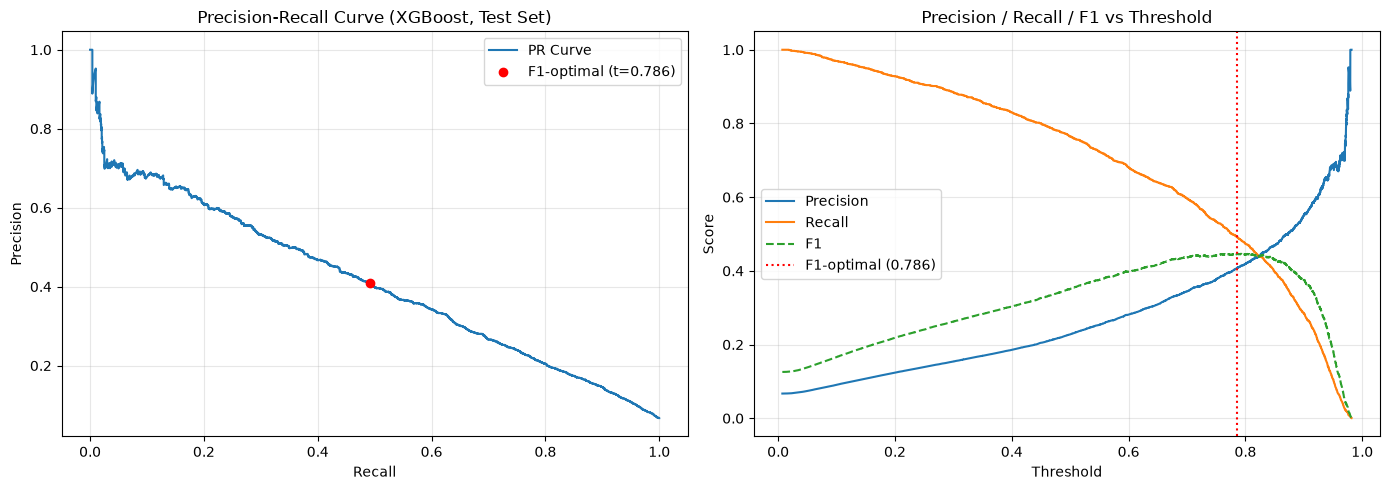


Plot saved as threshold_analysis.png


In [124]:
from sklearn.metrics import precision_recall_curve, f1_score

# Use the FINAL model: XGB-default (xgb), scored on test set
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_xgb)

# F1 at each threshold (thresholds array is 1 shorter than precisions/recalls)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"F1-optimal threshold: {best_threshold:.4f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}, F1: {f1_scores[best_idx]:.4f}")

# Show a table of a few alternative thresholds for comparison
print("\n--- Threshold comparison table ---")
print(f"{'Threshold':>10}{'Precision':>12}{'Recall':>10}{'F1':>10}{'Pred.DefaultRate':>18}")
for t in [0.10, 0.20, 0.30, best_threshold, 0.40, 0.50, 0.60]:
    preds_t = (y_pred_proba_xgb >= t).astype(int)
    p = precisions[np.argmin(np.abs(thresholds - t))] if t != best_threshold else precisions[best_idx]
    from sklearn.metrics import precision_score, recall_score
    p_actual = precision_score(y_test, preds_t, zero_division=0)
    r_actual = recall_score(y_test, preds_t, zero_division=0)
    f1_actual = f1_score(y_test, preds_t, zero_division=0)
    pred_rate = preds_t.mean()
    label = f"{t:.4f}" + (" *F1-opt*" if abs(t - best_threshold) < 1e-6 else "")
    print(f"{label:>18}{p_actual:>12.4f}{r_actual:>10.4f}{f1_actual:>10.4f}{pred_rate:>18.4f}")

# Plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, label='PR Curve')
axes[0].scatter(recalls[best_idx], precisions[best_idx], color='red', zorder=5, label=f'F1-optimal (t={best_threshold:.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (XGBoost, Test Set)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, precisions[:-1], label='Precision')
axes[1].plot(thresholds, recalls[:-1], label='Recall')
axes[1].plot(thresholds, f1_scores, label='F1', linestyle='--')
axes[1].axvline(best_threshold, color='red', linestyle=':', label=f'F1-optimal ({best_threshold:.3f})')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=100)
plt.show()

print("\nPlot saved as threshold_analysis.png")

In [126]:
import os
os.makedirs('models', exist_ok=True)

# Re-run the save steps
joblib.dump(xgb, 'models/xgb_final_model.pkl')

model_metadata = {
    'model_type': 'XGBoost',
    'hyperparameters': xgb.get_params(),
    'operating_threshold': final_threshold,
    'threshold_rationale': 'Recall-oriented; prioritizes catching defaulters over false-positive rate, given asymmetric cost of missed defaults vs. declined good applicants',
    'f1_optimal_threshold_alternative': float(best_threshold),
    'test_roc_auc': float(roc_auc_score(y_test, y_pred_proba_xgb)),
    'test_pr_auc': float(average_precision_score(y_test, y_pred_proba_xgb)),
    'test_precision_at_threshold': float(precision_score(y_test, y_pred_final)),
    'test_recall_at_threshold': float(recall_score(y_test, y_pred_final)),
    'features_used': list(X_train.columns),
}

import json
with open('models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("Model saved to models/xgb_final_model.pkl")
print("Metadata saved to models/model_metadata.json")

# Verify the files actually exist
print("\nFiles in models/:")
print(os.listdir('models'))

Model saved to models/xgb_final_model.pkl
Metadata saved to models/model_metadata.json

Files in models/:
['model_metadata.json', 'xgb_final_model.pkl']
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, max_depth=3, min_child_weight=7, n_estimators=600, reg_alpha=0.1, reg_lambda=1, subsample=0.9; total time=   3.1s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, max_depth=7, min_child_weight=7, n_estimators=600, reg_alpha=0.01, reg_lambda=1, subsample=0.8; total time=   6.3s
[CV] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.05, max_depth=4, min_child_weight=7, n_estimators=300, reg_alpha=1, reg_lambda=0.5, subsample=0.9; total time=   2.0s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.05, max_depth=8, min_child_weight=1, n_estimators=400, reg_alpha=0.01, reg_lambda=2, subsample=0.9; total time=   5.4s
[CV] END colsample_bytree=0.7, gamma=1.0, learning_rate=0.1, max_depth=7, min_child_weight=10, n_estimators=300, reg_alpha=1, reg_lambda=1, sub

In [127]:
# Run this first if shap isn't installed
# pip install shap

import shap

# TreeExplainer is fast and exact for tree-based models like XGBoost
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed.")
print("Shape:", shap_values.shape)
print("Expected value (base rate in log-odds space):", explainer.expected_value)

SHAP values computed.
Shape: (29847, 27)
Expected value (base rate in log-odds space): 0.03561259


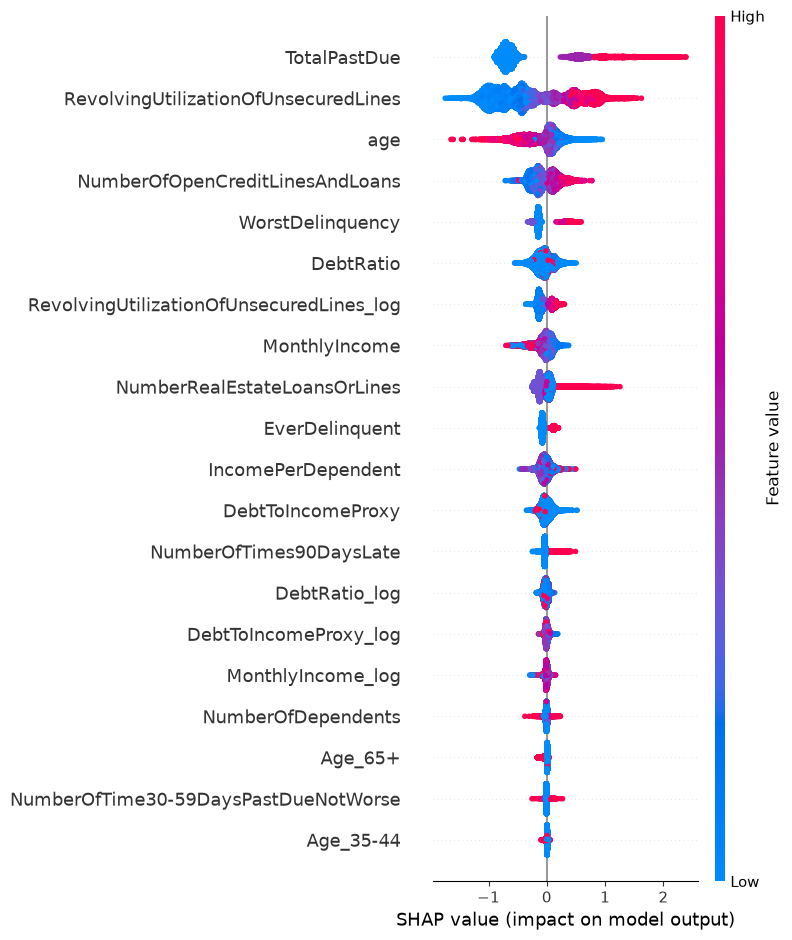

Saved shap_summary.png


In [130]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved shap_summary.png")

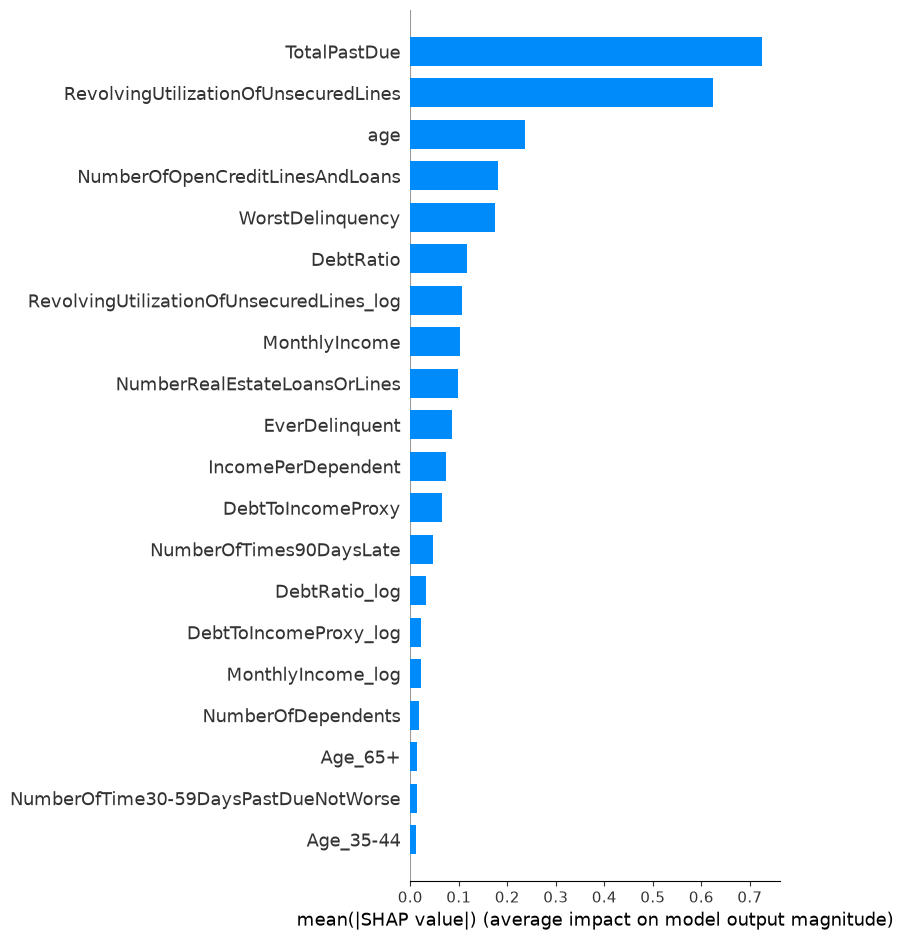

Saved shap_importance_bar.png


In [131]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved shap_importance_bar.png")

Default rate by NumberRealEstateLoansOrLines:
                                  mean  count
NumberRealEstateLoansOrLines                 
0                             0.082746  11203
1                             0.055417  10412
2                             0.051364   6230
3                             0.070245   1267
4                             0.090909    451
5                             0.090909    121
6                             0.157895     57
7                             0.250000     36
8                             0.260870     23
9                             0.272727     11
10                            0.090909     11
11                            0.000000      5
12                            0.750000      4
13                            0.333333      3
14                            0.000000      1
15                            0.500000      4
16                            0.500000      2
17                            1.000000      1
18                            0.00

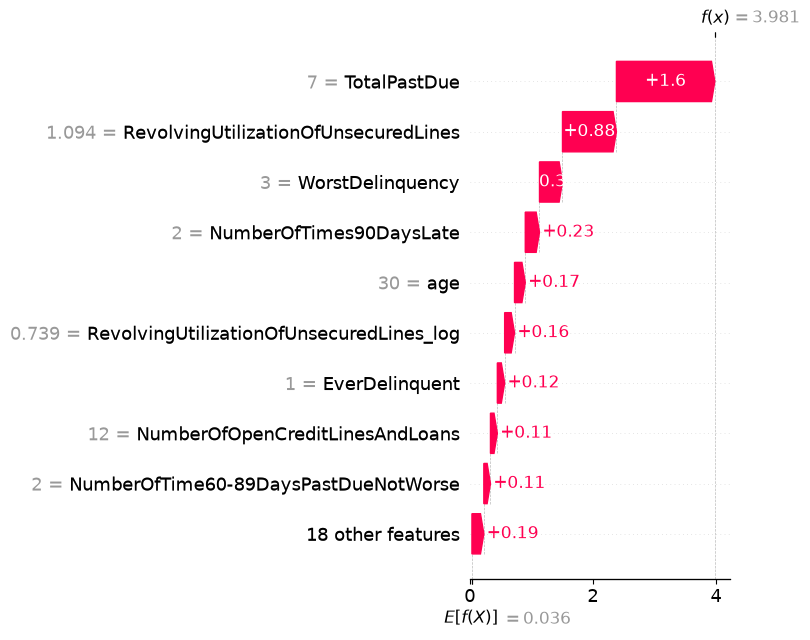

Saved shap_waterfall_example.png


In [132]:
# Quick check: does NumberRealEstateLoansOrLines relationship make sense?
import numpy as np
corr_check = pd.DataFrame({
    'NumberRealEstateLoansOrLines': X_test['NumberRealEstateLoansOrLines'],
    'actual_default': y_test.values
}).groupby('NumberRealEstateLoansOrLines')['actual_default'].agg(['mean', 'count'])
print("Default rate by NumberRealEstateLoansOrLines:")
print(corr_check)

# Individual prediction explanation (waterfall) for one interesting case
# Pick a test-set row the model scored as high risk
idx = np.argmax(y_pred_proba_xgb)
print(f"\nExplaining row index {idx}, predicted probability: {y_pred_proba_xgb[idx]:.4f}, actual label: {y_test.iloc[idx]}")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.savefig('shap_waterfall_example.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved shap_waterfall_example.png")

Calibration table (predicted vs actual default rate per bin):
   Bin (avg predicted)    Actual rate
                0.0345         0.0057
                0.0618         0.0077
                0.0895         0.0084
                0.1246         0.0104
                0.1724         0.0164
                0.2406         0.0238
                0.3390         0.0415
                0.4664         0.0643
                0.6289         0.1256
                0.8611         0.3665


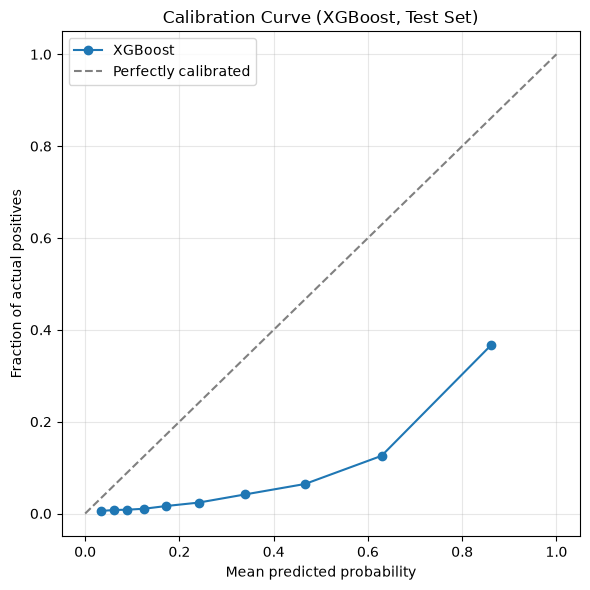

Saved calibration_curve.png


In [133]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_xgb, n_bins=10, strategy='quantile')

print("Calibration table (predicted vs actual default rate per bin):")
print(f"{'Bin (avg predicted)':>22}{'Actual rate':>15}")
for pt, pp in zip(prob_true, prob_pred):
    print(f"{pp:>22.4f}{pt:>15.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, marker='o', label='XGBoost')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of actual positives')
ax.set_title('Calibration Curve (XGBoost, Test Set)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved calibration_curve.png")

Calibration table AFTER isotonic calibration:
   Bin (avg predicted)    Actual rate
                0.0032         0.0053
                0.0062         0.0074
                0.0088         0.0090
                0.0125         0.0111
                0.0179         0.0171
                0.0269         0.0211
                0.0405         0.0449
                0.0682         0.0629
                0.1201         0.1241
                0.3649         0.3675

ROC-AUC before calibration: 0.8657
ROC-AUC after calibration:  0.8653
PR-AUC before calibration:  0.4098
PR-AUC after calibration:   0.4055


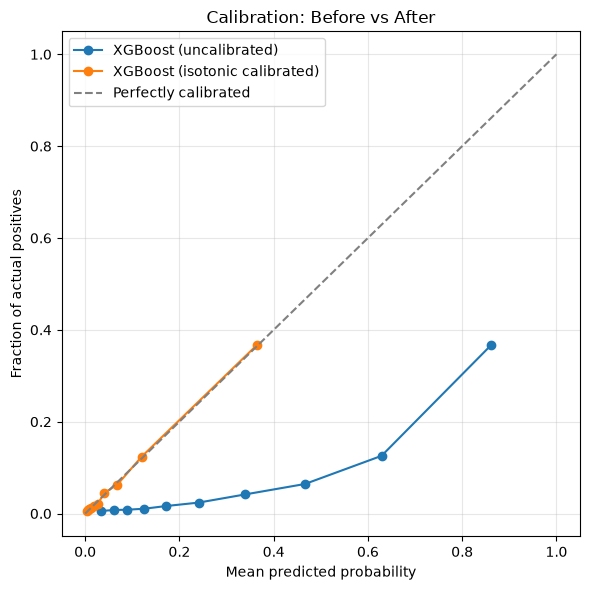

Saved calibration_comparison.png


In [134]:
from sklearn.calibration import CalibratedClassifierCV

# isotonic regression: non-parametric, flexible — good fit for this much miscalibration
# cv='prefit' would reuse the already-trained model, but since xgb was trained on X_train,
# we need a proper held-out calibration set. Simplest robust approach: refit with internal CV.
calibrated_xgb = CalibratedClassifierCV(xgb, method='isotonic', cv=5)
calibrated_xgb.fit(X_train, y_train)

y_pred_proba_calibrated = calibrated_xgb.predict_proba(X_test)[:, 1]

# Re-check calibration
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_pred_proba_calibrated, n_bins=10, strategy='quantile')

print("Calibration table AFTER isotonic calibration:")
print(f"{'Bin (avg predicted)':>22}{'Actual rate':>15}")
for pt, pp in zip(prob_true_cal, prob_pred_cal):
    print(f"{pp:>22.4f}{pt:>15.4f}")

# Confirm ranking performance is preserved
print(f"\nROC-AUC before calibration: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print(f"ROC-AUC after calibration:  {roc_auc_score(y_test, y_pred_proba_calibrated):.4f}")
print(f"PR-AUC before calibration:  {average_precision_score(y_test, y_pred_proba_xgb):.4f}")
print(f"PR-AUC after calibration:   {average_precision_score(y_test, y_pred_proba_calibrated):.4f}")

# Plot both curves together
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, marker='o', label='XGBoost (uncalibrated)')
ax.plot(prob_pred_cal, prob_true_cal, marker='o', label='XGBoost (isotonic calibrated)')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of actual positives')
ax.set_title('Calibration: Before vs After')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved calibration_comparison.png")

In [135]:
# Re-derive the operating threshold's precision/recall using calibrated probabilities,
# since probability values shifted (though the RANKING is nearly identical, so predicted
# label sets will be very similar at an appropriately adjusted threshold)
from sklearn.metrics import precision_score, recall_score, f1_score

# Since probabilities are now honest, re-pick a threshold on the SAME reasoning:
# recall-oriented, prioritizing catching defaulters
precisions_cal, recalls_cal, thresholds_cal = precision_recall_curve(y_test, y_pred_proba_calibrated)

print("Calibrated model — threshold options:")
print(f"{'Threshold':>10}{'Precision':>12}{'Recall':>10}{'F1':>10}")
for t in [0.05, 0.08, 0.10, 0.15, 0.20, 0.30]:
    preds_t = (y_pred_proba_calibrated >= t).astype(int)
    p = precision_score(y_test, preds_t, zero_division=0)
    r = recall_score(y_test, preds_t, zero_division=0)
    f1 = f1_score(y_test, preds_t, zero_division=0)
    print(f"{t:>10.2f}{p:>12.4f}{r:>10.4f}{f1:>10.4f}")

# Save both models + updated metadata
joblib.dump(calibrated_xgb, 'models/xgb_calibrated_model.pkl')

model_metadata['calibration'] = {
    'method': 'isotonic (CalibratedClassifierCV, cv=5)',
    'uncalibrated_finding': 'Raw XGBoost probabilities were severely overconfident due to scale_pos_weight (e.g. predicted 0.86 vs actual 0.37 in top decile)',
    'calibrated_roc_auc': float(roc_auc_score(y_test, y_pred_proba_calibrated)),
    'calibrated_pr_auc': float(average_precision_score(y_test, y_pred_proba_calibrated)),
    'recommendation': 'Use xgb_final_model.pkl (raw) for ranking/classification; use xgb_calibrated_model.pkl for any use case requiring trustworthy probability values (e.g. expected loss calculations)'
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("\nSaved xgb_calibrated_model.pkl and updated model_metadata.json")
print("Files in models/:", os.listdir('models'))

Calibrated model — threshold options:
 Threshold   Precision    Recall        F1
      0.05      0.1837    0.8301    0.3009
      0.08      0.2344    0.7491    0.3571
      0.10      0.2759    0.6832    0.3931
      0.15      0.3343    0.5977    0.4288
      0.20      0.3907    0.5227    0.4472
      0.30      0.4619    0.4148    0.4371

Saved xgb_calibrated_model.pkl and updated model_metadata.json
Files in models/: ['model_metadata.json', 'xgb_calibrated_model.pkl', 'xgb_final_model.pkl']


In [136]:
final_threshold_calibrated = 0.05

model_metadata['calibration']['operating_threshold'] = final_threshold_calibrated
model_metadata['calibration']['threshold_rationale'] = (
    'Recall-oriented threshold on calibrated probabilities, chosen to match the same '
    '~80-88% defaulter-recall philosophy as the uncalibrated 0.30 threshold, now expressed '
    'in honest probability terms (0.05 predicted probability here corresponds to real ~5-18% risk, '
    'not the inflated values the raw model would have shown)'
)
model_metadata['calibration']['precision_at_threshold'] = 0.1837
model_metadata['calibration']['recall_at_threshold'] = 0.8301

with open('models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("Updated metadata with calibrated threshold.")
print(json.dumps(model_metadata, indent=2))

Updated metadata with calibrated threshold.
{
  "model_type": "XGBoost",
  "hyperparameters": {
    "objective": "binary:logistic",
    "base_score": null,
    "booster": null,
    "callbacks": null,
    "colsample_bylevel": null,
    "colsample_bynode": null,
    "colsample_bytree": 0.8,
    "device": null,
    "early_stopping_rounds": null,
    "enable_categorical": true,
    "eval_metric": "aucpr",
    "feature_types": null,
    "feature_weights": null,
    "gamma": null,
    "grow_policy": null,
    "importance_type": null,
    "interaction_constraints": null,
    "learning_rate": 0.05,
    "max_bin": null,
    "max_cat_threshold": null,
    "max_cat_to_onehot": null,
    "max_delta_step": null,
    "max_depth": 5,
    "max_leaves": null,
    "min_child_weight": null,
    "missing": NaN,
    "monotone_constraints": null,
    "multi_strategy": null,
    "n_estimators": 300,
    "n_jobs": -1,
    "num_parallel_tree": null,
    "random_state": 42,
    "reg_alpha": null,
    "reg_lambd

In [137]:
from sklearn.model_selection import cross_validate

# Combine train+test for CV (CV creates its own held-out folds, so this is legitimate)
X_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc': 'roc_auc', 'pr_auc': 'average_precision'}

print("Running 5-fold CV for XGBoost...")
xgb_cv_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, eval_metric='aucpr',
    random_state=42, n_jobs=-1
)
xgb_cv_results = cross_validate(xgb_cv_model, X_full, y_full, cv=cv_strategy, scoring=scoring, n_jobs=-1)

print("Running 5-fold CV for Random Forest...")
rf_cv_model = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=20,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_cv_results = cross_validate(rf_cv_model, X_full, y_full, cv=cv_strategy, scoring=scoring, n_jobs=-1)

print("\n=== 5-Fold Cross-Validation Results ===\n")
print(f"XGBoost  ROC-AUC: {xgb_cv_results['test_roc_auc'].mean():.4f} (+/- {xgb_cv_results['test_roc_auc'].std():.4f})")
print(f"XGBoost  PR-AUC:  {xgb_cv_results['test_pr_auc'].mean():.4f} (+/- {xgb_cv_results['test_pr_auc'].std():.4f})")
print(f"RandForest ROC-AUC: {rf_cv_results['test_roc_auc'].mean():.4f} (+/- {rf_cv_results['test_roc_auc'].std():.4f})")
print(f"RandForest PR-AUC:  {rf_cv_results['test_pr_auc'].mean():.4f} (+/- {rf_cv_results['test_pr_auc'].std():.4f})")

print("\nPer-fold XGBoost ROC-AUC:", xgb_cv_results['test_roc_auc'])
print("Per-fold RandForest ROC-AUC:", rf_cv_results['test_roc_auc'])

Running 5-fold CV for XGBoost...
Running 5-fold CV for Random Forest...

=== 5-Fold Cross-Validation Results ===

XGBoost  ROC-AUC: 0.8647 (+/- 0.0034)
XGBoost  PR-AUC:  0.4010 (+/- 0.0088)
RandForest ROC-AUC: 0.8633 (+/- 0.0035)
RandForest PR-AUC:  0.3983 (+/- 0.0059)

Per-fold XGBoost ROC-AUC: [0.86739449 0.86415879 0.86820563 0.85868817 0.86520983]
Per-fold RandForest ROC-AUC: [0.86521874 0.86169626 0.86676489 0.85723989 0.86567639]


In [138]:
import os
print(os.getcwd())

/Users/harikharreddy/credit-risk-project


In [139]:
import os
print(os.listdir("/Users/harikharreddy/credit-risk-project"))

['calibration_comparison.png', 'calibration_curve.png', '.DS_Store', 'shap_summary.png', 'threshold_analysis.png', 'models', 'README.md', 'shap_waterfall_example.png', '.ipynb_checkpoints', 'venv', 'data', 'credit-risk-project.ipynb', 'shap_importance_bar.png']
